<a href="https://colab.research.google.com/github/marcolari06-maker/loan-default-prediction/blob/main/LDP_DMML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loan default prediction  

In [1]:
import pandas as pd

In [2]:
github_csv_url = 'https://raw.githubusercontent.com/marcolari06-maker/loan-default-prediction/refs/heads/main/dataset.csv'

try:
    df_github = pd.read_csv(github_csv_url)
    print("Dataset loaded from github repo loan-default-prediction")
    display(df_github.head())
    print(df_github.shape[0])
except Exception as e:
    print(f"Errore durante il caricamento del dataset da GitHub: {e}")

Dataset loaded from github repo loan-default-prediction


,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


148670


In [3]:
print("Informazioni sul dataset (nomi delle feature e tipi di dati):")
df_github.info()

Informazioni sul dataset (nomi delle feature e tipi di dati):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         148670 non-null  int64  
 1   year                       148670 non-null  int64  
 2   loan_limit                 145326 non-null  object 
 3   Gender                     148670 non-null  object 
 4   approv_in_adv              147762 non-null  object 
 5   loan_type                  148670 non-null  object 
 6   loan_purpose               148536 non-null  object 
 7   Credit_Worthiness          148670 non-null  object 
 8   open_credit                148670 non-null  object 
 9   business_or_commercial     148670 non-null  object 
 10  loan_amount                148670 non-null  int64  
 11  rate_of_interest           112231 non-null  float64
 12  Interest_rate_spread    

### Analisi dei tipi di valori per ogni attributo

In [4]:
for column in df_github.columns:
    print(f"\n--- Attributo: {column} ---")
    if df_github[column].dtype in ['int64', 'float64']:
        print("Tipo: Numerico")
        print("Statistiche descrittive:")
        print(df_github[column].describe())
        # Consider if it might be meta-numeric (numeric values used as labels)
        unique_numeric_values = df_github[column].nunique()
        if unique_numeric_values < 20 and unique_numeric_values > 0:
            print(f"Potenzialmente meta-numerico o categorico con {unique_numeric_values} valori unici (es. codici, flag):\n{df_github[column].value_counts().sort_index()}")
    elif df_github[column].dtype == 'object':
        print("Tipo: Letterale (categorico)")
        print("Valori unici e loro frequenze:")
        print(df_github[column].value_counts(dropna=False))
    else:
        print(f"Tipo: Altro ({df_github[column].dtype})")



--- Attributo: ID ---
Tipo: Numerico
Statistiche descrittive:
count    148670.000000
mean      99224.500000
std       42917.476598
min       24890.000000
25%       62057.250000
50%       99224.500000
75%      136391.750000
max      173559.000000
Name: ID, dtype: float64

--- Attributo: year ---
Tipo: Numerico
Statistiche descrittive:
count    148670.0
mean       2019.0
std           0.0
min        2019.0
25%        2019.0
50%        2019.0
75%        2019.0
max        2019.0
Name: year, dtype: float64
Potenzialmente meta-numerico o categorico con 1 valori unici (es. codici, flag):
year
2019    148670
Name: count, dtype: int64

--- Attributo: loan_limit ---
Tipo: Letterale (categorico)
Valori unici e loro frequenze:
loan_limit
cf     135348
ncf      9978
NaN      3344
Name: count, dtype: int64

--- Attributo: Gender ---
Tipo: Letterale (categorico)
Valori unici e loro frequenze:
Gender
Male                 42346
Joint                41399
Sex Not Available    37659
Female              

In [5]:

print("Analisi dei valori mancanti per ogni attributo")
missing = df_github.isnull().sum()
missing_pct = (missing / len(df_github) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Values': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

# Mostra solo le colonne che hanno almeno 1 NaN
print(missing_df[missing_df['Missing Values'] > 0])

Analisi dei valori mandancti per ogni attributo
                           Missing Values  Missing %
Upfront_charges                     39642      26.66
Interest_rate_spread                36639      24.64
rate_of_interest                    36439      24.51
dtir1                               24121      16.22
property_value                      15098      10.16
LTV                                 15098      10.16
income                               9150       6.15
loan_limit                           3344       2.25
approv_in_adv                         908       0.61
age                                   200       0.13
submission_of_application             200       0.13
loan_purpose                          134       0.09
Neg_ammortization                     121       0.08
term                                   41       0.03




*   UPFRONT CHARGES --> MISSING/NOT IS MUCH MORE INFORMATIVE THAN THE VALUE ITSELF, IT COULD BE CHANGED IN A BINARY VALUE.
*   INTEREST RATE SPREAD --> Da levare perchè palese leakage
*   RATE OF INTEREST --> situazione analoga, probabilmente i record con default sono stati aggiunti dopo senza queste misure
*   DTIR1 --> sostituito con la mediana, la distribuzione è abbastanza simmetrica e la correlazione con status bassa.
*   PROPERTY VALUE e LTV --> quando manca è default, quando c'è non è detto, potrebbe aver senso levare i record in cui sono null (corrispondono)
*   INCOME --> sostituito con la mediana per lo stesso motivo di dtr1
*   LOAN LIMIT --> binaria, sostituire con la moda (cf) o valutare di introdurre una nuova categoria "unknown" evitando bias (DECIDERE)
*   AGE --> 200 record in cui manca e sono tutti default, si può togliere (DECIDERE)
*   SUBMISSION OF APPLICATION -> stesso di age (DECIDERE)
*   loan_purpose -> possiamo mettere la moda (i valori nulli sono pochi e comunque loan_purpose non è correlato con Status -> DECIDERE)
*   Neg_ammortization -> stesso discorso di sopra (DECIDERE)
*   term -> idem (DECIDERE)



#Analisi valori mancanti


###Upfront charges

In [6]:
# Creazione di una variabile binaria per indicare la presenza di valori mancanti in 'Upfront_charges'
df_github['Upfront_charges_missing'] = df_github['Upfront_charges'].isnull().astype(int)

# Creazione della tabella di contingenza
contingency_table_upfront_missing = pd.crosstab(df_github['Upfront_charges_missing'], df_github['Status'])
df_github = df_github.drop(columns=['Upfront_charges_missing'])
print("Tabella di Contingenza: Upfront_charges_missing vs Status")
display(contingency_table_upfront_missing)

Tabella di Contingenza: Upfront_charges_missing vs Status


Status,0,1
Upfront_charges_missing,,
0,108875,153
1,3156,36486


###Interest_rate_spread e rate_of_interest

In [7]:
# Create a binary flag: 1 if missing, 0 if present
df_github['Interest_rate_spread_is_missing'] = df_github['Interest_rate_spread'].isnull().astype(int)

# Generate the contingency table
leakage_table = pd.crosstab(df_github['Interest_rate_spread_is_missing'], df_github['Status'], margins=True)
df_github = df_github.drop(columns=['Interest_rate_spread_is_missing'])
print("Contingency Table: Interest_rate_spread_is_missing (Row) vs Status (Column)")
display(leakage_table)

Contingency Table: Interest_rate_spread_is_missing (Row) vs Status (Column)


Status,0,1,All
Interest_rate_spread_is_missing,,,
0,112031,0,112031
1,0,36639,36639
All,112031,36639,148670


In [8]:
# Create a binary flag: 1 if missing, 0 if present
df_github['ROImissing'] = df_github['rate_of_interest'].isnull().astype(int)

# Generate the contingency table
leakage_table = pd.crosstab(df_github['ROImissing'], df_github['Status'], margins=True)
df_github = df_github.drop(columns=['ROImissing'])
print("Contingency Table: ROImissing (Row) vs Status (Column)")
display(leakage_table)

Contingency Table: ROImissing (Row) vs Status (Column)


Status,0,1,All
ROImissing,,,
0,112031,200,112231
1,0,36439,36439
All,112031,36639,148670


###dtr1

In [9]:
# Create a binary flag: 1 if missing, 0 if present
df_github['dtir1_ismissing'] = df_github['dtir1'].isnull().astype(int)

# Generate the contingency table
leakage_table = pd.crosstab(df_github['dtir1_ismissing'], df_github['Status'], margins=True)
df_github = df_github.drop(columns=['dtir1_ismissing'])
print("Contingency Table: dtir1_ismissing (Row) vs Status (Column)")
display(leakage_table)

Contingency Table: dtir1_ismissing (Row) vs Status (Column)


Status,0,1,All
dtir1_ismissing,,,
0,104220,20329,124549
1,7811,16310,24121
All,112031,36639,148670


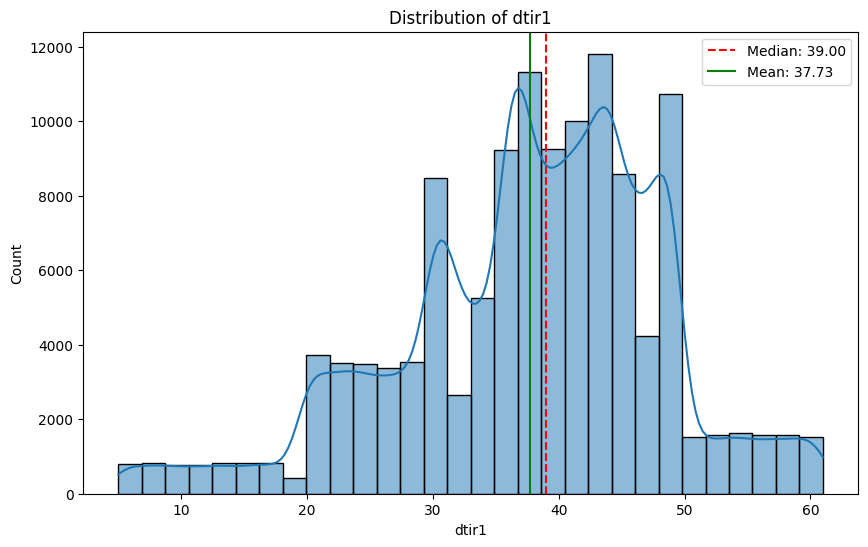

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df_github['dtir1'].dropna(), kde=True, bins=30)
plt.title('Distribution of dtir1')
plt.axvline(df_github['dtir1'].median(), color='red', linestyle='--', label=f'Median: {df_github["dtir1"].median():.2f}')
plt.axvline(df_github['dtir1'].mean(), color='green', linestyle='-', label=f'Mean: {df_github["dtir1"].mean():.2f}')
plt.legend()
plt.show()

Given the distribution, the median is a safe choice for basic imputation. I'll also add a flag so the model knows the value was originally missing (which preserves that information).

In [11]:

# Create quartiles for dtir1
# We use 'duplicates=drop' just in case the distribution is heavily skewed at certain values
df_github['dtir1_quartiles'] = pd.qcut(df_github['dtir1'], q=4)

# Generate the contingency table
ct_quartiles = pd.crosstab(df_github['dtir1_quartiles'], df_github['Status'], normalize='index') * 100
ct_counts = pd.crosstab(df_github['dtir1_quartiles'], df_github['Status'])

print("Contingency Table (Percentages per Quartile):")
display(ct_quartiles)

print("\nContingency Table (Raw Counts):")
display(ct_counts)

Contingency Table (Percentages per Quartile):


Status,0,1
dtir1_quartiles,,
"(4.999, 31.0]",85.012430,14.987570
"(31.0, 39.0]",87.800437,12.199563
"(39.0, 45.0]",86.106446,13.893554
"(45.0, 61.0]",74.751344,25.248656



Contingency Table (Raw Counts):


Status,0,1
dtir1_quartiles,,
"(4.999, 31.0]",27357,4823
"(31.0, 39.0]",28932,4020
"(39.0, 45.0]",26662,4302
"(45.0, 61.0]",21269,7184


In [12]:
# Reverting to median imputation for dtir1
median_val = df_github['dtir1'].median()
df_github['dtir1'] = df_github['dtir1'].fillna(median_val)

print(f"Imputation complete. Missing values in 'dtir1': {df_github['dtir1'].isnull().sum()}")
print(f"Median value used: {median_val}")

Imputation complete. Missing values in 'dtir1': 0
Median value used: 39.0


###Property value


In [13]:
# Create a binary flag: 1 if missing, 0 if present
df_github['property_value_is_missing'] = df_github['property_value'].isnull().astype(int)

# Generate the contingency table
leakage_table = pd.crosstab(df_github['property_value_is_missing'], df_github['Status'], margins=True)
df_github = df_github.drop(columns=['property_value_is_missing'])
print("Contingency Table: property_value_is_missing (Row) vs Status (Column)")
display(leakage_table)

Contingency Table: property_value_is_missing (Row) vs Status (Column)


Status,0,1,All
property_value_is_missing,,,
0,112029,21543,133572
1,2,15096,15098
All,112031,36639,148670


###LTV


In [14]:
# Create a binary flag: 1 if missing, 0 if present
df_github['LTV_is_missing'] = df_github['LTV'].isnull().astype(int)

# Generate the contingency table
leakage_table = pd.crosstab(df_github['LTV_is_missing'], df_github['Status'], margins=True)
df_github = df_github.drop(columns=['LTV_is_missing'])
print("Contingency Table: LTV_is_missing (Row) vs Status (Column)")
display(leakage_table)

Contingency Table: LTV_is_missing (Row) vs Status (Column)


Status,0,1,All
LTV_is_missing,,,
0,112029,21543,133572
1,2,15096,15098
All,112031,36639,148670


###Income

In [15]:
# Create a binary flag: 1 if missing, 0 if present
df_github['income_missing'] = df_github['income'].isnull().astype(int)

# Generate the contingency table
leakage_table = pd.crosstab(df_github['income_missing'], df_github['Status'], margins=True)
df_github = df_github.drop(columns=['income_missing'])
print("Contingency Table: income_missing (Row) vs Status (Column)")
display(leakage_table)

Contingency Table: income_missing (Row) vs Status (Column)


Status,0,1,All
income_missing,,,
0,104120,35400,139520
1,7911,1239,9150
All,112031,36639,148670


In [16]:
# Create quartiles for dtir1
# We use 'duplicates=drop' just in case the distribution is heavily skewed at certain values
df_github['income_quart'] = pd.qcut(df_github['income'], q=4)

# Generate the contingency table
ct_quartiles = pd.crosstab(df_github['income_quart'], df_github['Status'], normalize='index') * 100
ct_counts = pd.crosstab(df_github['income_quart'], df_github['Status'])

print("Contingency Table (Percentages per Quartile):")
display(ct_quartiles)

print("\nContingency Table (Raw Counts):")
display(ct_counts)

Contingency Table (Percentages per Quartile):


Status,0,1
income_quart,,
"(-0.001, 3720.0]",64.487808,35.512192
"(3720.0, 5760.0]",75.472125,24.527875
"(5760.0, 8520.0]",78.998601,21.001399
"(8520.0, 578580.0]",79.780220,20.219780



Contingency Table (Raw Counts):


Status,0,1
income_quart,,
"(-0.001, 3720.0]",22770,12539
"(3720.0, 5760.0]",26656,8663
"(5760.0, 8520.0]",27106,7206
"(8520.0, 578580.0]",27588,6992


In [17]:
median_val = df_github['income'].median()
df_github['income'] = df_github['income'].fillna(median_val)

print(f"Imputation complete. Missing values in 'income': {df_github['income'].isnull().sum()}")
print(f"Median value used: {median_val}")

Imputation complete. Missing values in 'income': 0
Median value used: 5760.0


###Loan Limit

In [18]:
# Create a binary flag: 1 if missing, 0 if present
df_github['LL_missing'] = df_github['loan_limit'].isnull().astype(int)

# Generate the contingency table
leakage_table = pd.crosstab(df_github['LL_missing'], df_github['Status'], margins=True)
df_github = df_github.drop(columns=['LL_missing'])
print("Contingency Table: LL_missing (Row) vs Status (Column)")
display(leakage_table)

Contingency Table: LL_missing (Row) vs Status (Column)


Status,0,1,All
LL_missing,,,
0,109568,35758,145326
1,2463,881,3344
All,112031,36639,148670


### Age

In [19]:
# Create a binary flag: 1 if missing, 0 if present
df_github['age_missing'] = df_github['age'].isnull().astype(int)

# Generate the contingency table
leakage_table = pd.crosstab(df_github['age_missing'], df_github['Status'], margins=True)
df_github = df_github.drop(columns=['age_missing'])
print("Contingency Table: age_missing (Row) vs Status (Column)")
display(leakage_table)

Contingency Table: age_missing (Row) vs Status (Column)


Status,0,1,All
age_missing,,,
0,112031,36439,148470
1,0,200,200
All,112031,36639,148670


### Submission of application

In [20]:
# Create a binary flag: 1 if missing, 0 if present
df_github['submission_of_application_missing'] = df_github['submission_of_application'].isnull().astype(int)

# Generate the contingency table
leakage_table = pd.crosstab(df_github['submission_of_application_missing'], df_github['Status'], margins=True)
df_github = df_github.drop(columns=['submission_of_application_missing'])
print("Contingency Table: submission_of_application_missing (Row) vs Status (Column)")
display(leakage_table)

Contingency Table: submission_of_application_missing (Row) vs Status (Column)


Status,0,1,All
submission_of_application_missing,,,
0,112031,36439,148470
1,0,200,200
All,112031,36639,148670


In [21]:
import pandas as pd

# Create flags for missing values
age_is_nan = df_github['age'].isnull()
submission_is_nan = df_github['submission_of_application'].isnull()

# Create a contingency table to see the overlap
overlap_table = pd.crosstab(age_is_nan, submission_is_nan,
                            rownames=['Age Missing'],
                            colnames=['Submission Missing'],
                            margins=True)

print("Overlap between missing Age and missing Submission of Application:")
display(overlap_table)

# Explicitly check if the indices match
same_records = (df_github[age_is_nan].index == df_github[submission_is_nan].index).all()
print(f"\nDo both columns have missing values in exactly the same records? {same_records}")

Overlap between missing Age and missing Submission of Application:


Submission Missing,False,True,All
Age Missing,,,
False,148470,0,148470
True,0,200,200
All,148470,200,148670



Do both columns have missing values in exactly the same records? True


200 records with missing age are the same 200 records with missing submission_of_application.


### Loan Purpose


In [31]:
# Create a binary flag: 1 if missing, 0 if present
df_github['loan_purpose_missing'] = df_github['loan_purpose'].isnull().astype(int)

# Generate the contingency table
leakage_table = pd.crosstab(df_github['loan_purpose_missing'], df_github['Status'], margins=True)
df_github = df_github.drop(columns=['loan_purpose_missing'])
print("Contingency Table: loan_purpose_missing (Row) vs Status (Column)")
display(leakage_table)

Contingency Table: loan_purpose_missing (Row) vs Status (Column)


Status,0,1,All
loan_purpose_missing,,,
0,111932,36604,148536
1,99,35,134
All,112031,36639,148670


### Neg Ammortization

In [33]:
# Create a binary flag: 1 if missing, 0 if present
df_github['Neg_ammortization_missing'] = df_github['Neg_ammortization'].isnull().astype(int)

# Generate the contingency table
leakage_table = pd.crosstab(df_github['Neg_ammortization_missing'], df_github['Status'], margins=True)
df_github = df_github.drop(columns=['Neg_ammortization_missing'])
print("Contingency Table: Neg_ammortization_missing (Row) vs Status (Column)")
display(leakage_table)

Contingency Table: Neg_ammortization_missing (Row) vs Status (Column)


Status,0,1,All
Neg_ammortization_missing,,,
0,111942,36607,148549
1,89,32,121
All,112031,36639,148670


### Term

In [ ]:
# Create a binary flag: 1 if missing, 0 if present
df_github['term_missing'] = df_github['term'].isnull().astype(int)

# Generate the contingency table
leakage_table = pd.crosstab(df_github['term_missing'], df_github['Status'], margins=True)
df_github = df_github.drop(columns=['term_missing'])
print("Contingency Table: term_missing (Row) vs Status (Column)")
display(leakage_table)

Contingency Table: term_missing (Row) vs Status (Column)


Status,0,1,All
term_missing,,,
0,112005,36624,148629
1,26,15,41
All,112031,36639,148670


#AFTER

In [23]:
print("Tabella di Contingenza per Secured_by e Status:")
display(pd.crosstab(df_github['Secured_by'], df_github['Status'], margins=True))

Tabella di Contingenza per Secured_by e Status:


Status,0,1,All
Secured_by,,,
home,112031,36606,148637
land,0,33,33
All,112031,36639,148670


In [24]:
print("\nTabella di Contingenza per construction_type e Status:")
display(pd.crosstab(df_github['construction_type'], df_github['Status'], margins=True))


Tabella di Contingenza per construction_type e Status:


Status,0,1,All
construction_type,,,
mh,0,33,33
sb,112031,36606,148637
All,112031,36639,148670


In [25]:
print("\nTabella di Contingenza per Security_Type e Status:")
display(pd.crosstab(df_github['Security_Type'], df_github['Status'], margins=True))


Tabella di Contingenza per Security_Type e Status:


Status,0,1,All
Security_Type,,,
Indriect,0,33,33
direct,112031,36606,148637
All,112031,36639,148670


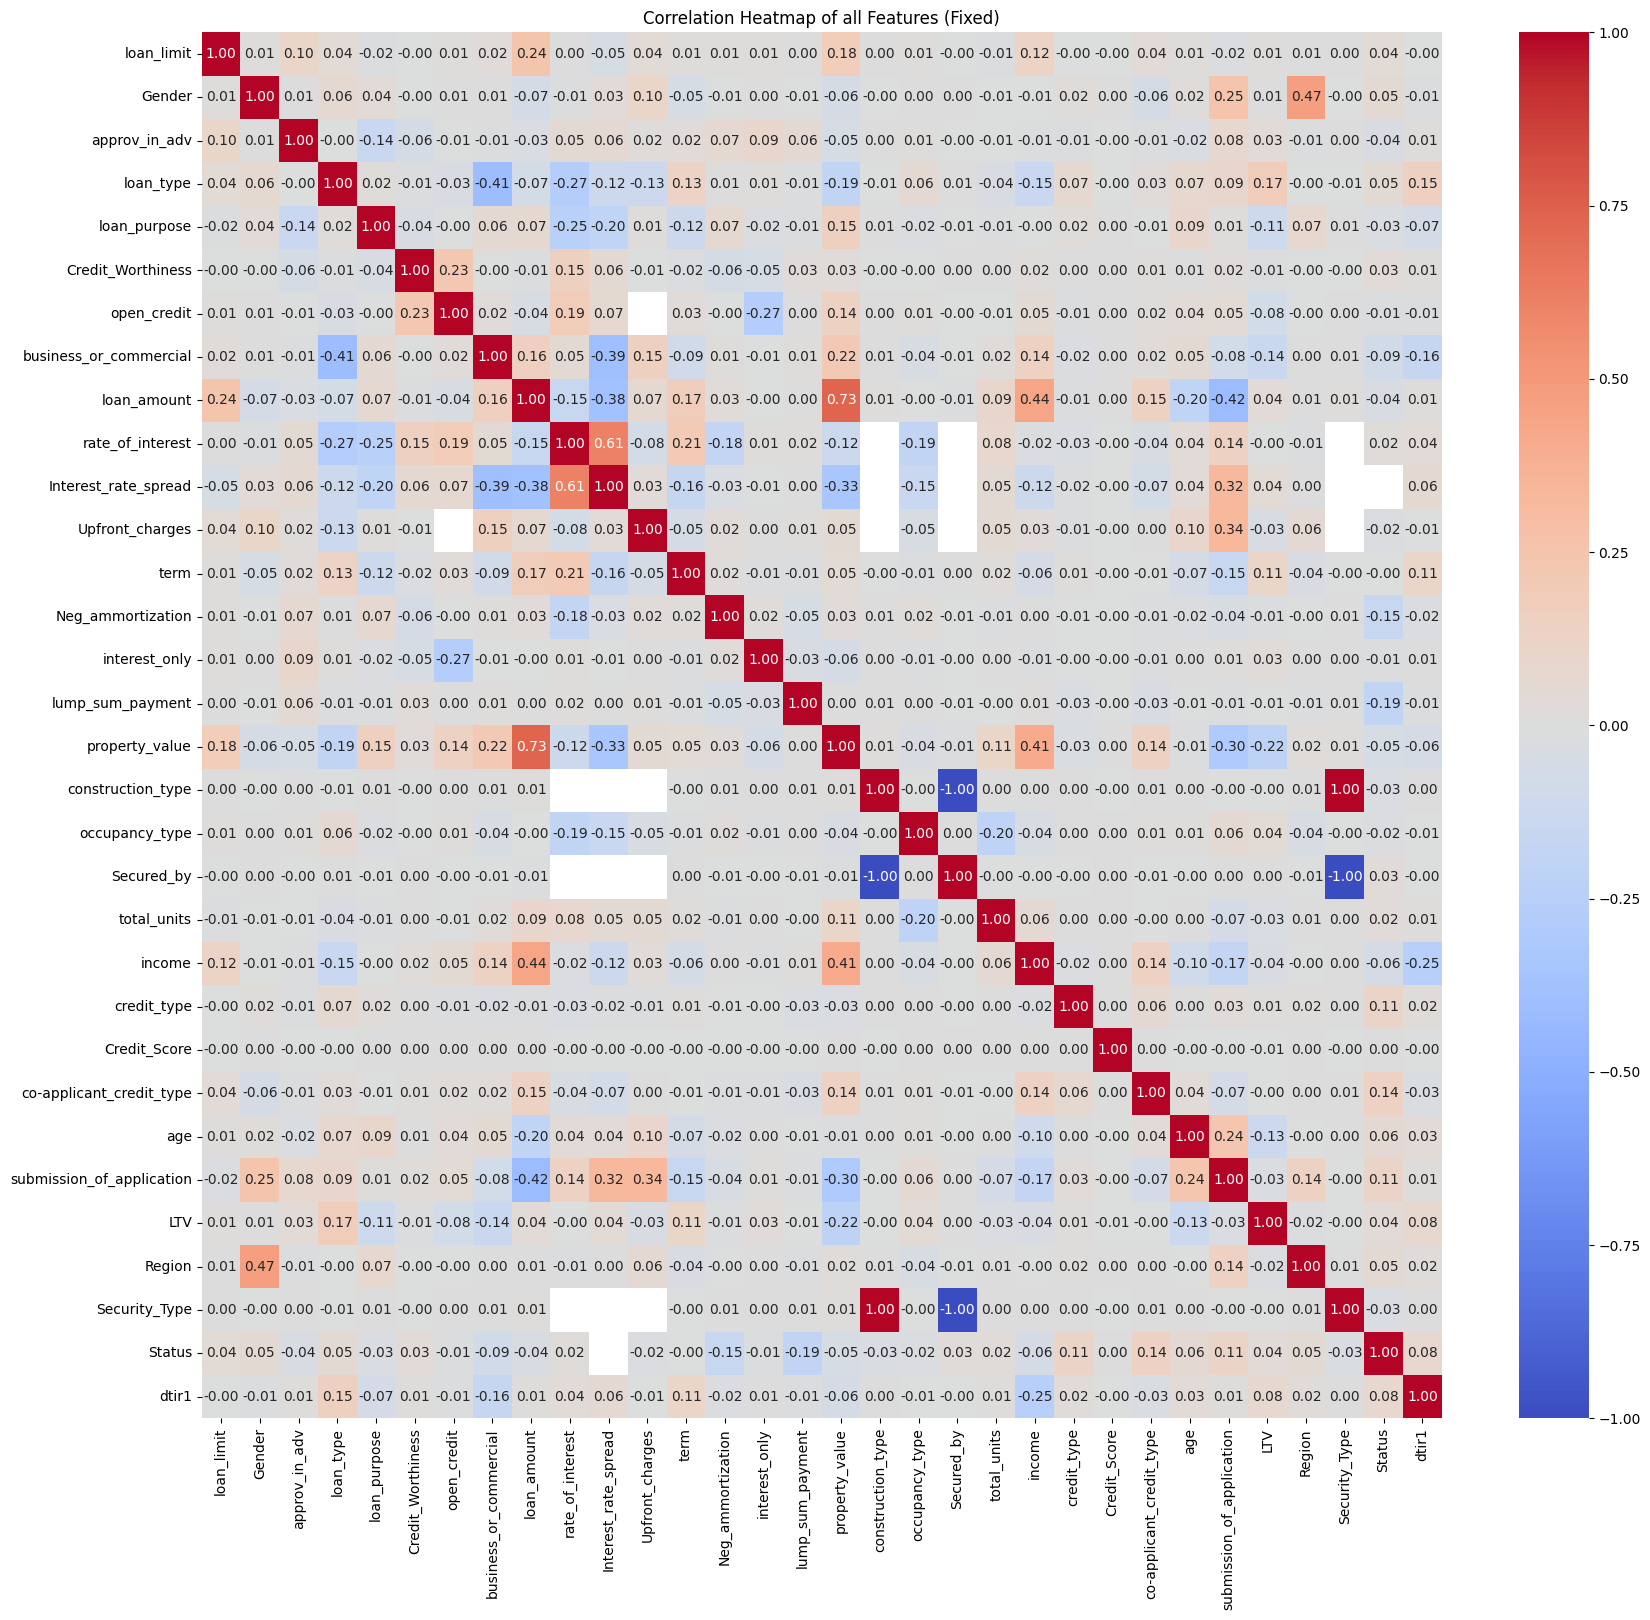

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Creazione di una copia del dataframe per l'analisi di correlazione
df_for_heatmap = df_github.copy()

# Rimuovi colonne identificative o costanti che non contribuiscono alla correlazione
# Aggiungiamo 'dtir1_quartiles' alla rimozione perché contiene oggetti Interval che causano il TypeError
df_for_heatmap = df_for_heatmap.drop(columns=['ID', 'year', 'dtir1_quartiles'], errors='ignore')

# Gestione delle colonne categoriche: codifica con Label Encoding
for column in df_for_heatmap.select_dtypes(include=['object']).columns:
    if df_for_heatmap[column].isnull().any():
        df_for_heatmap[column] = df_for_heatmap[column].fillna('Missing')
    le = LabelEncoder()
    df_for_heatmap[column] = le.fit_transform(df_for_heatmap[column])

# Escludiamo esplicitamente colonne non numeriche residue (come eventuali Interval o Categorical non convertiti)
df_for_heatmap = df_for_heatmap.select_dtypes(include=['number'])

# Calcola la matrice di correlazione
correlation_matrix = df_for_heatmap.corr()

# Traccia la heatmap con annotazioni numeriche
plt.figure(figsize=(20, 18))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of all Features (Fixed)')
plt.show()

Cose da fare su attributi:
- year si può togliere, tutti 2019
- approv_in_adv, dice già il risultato? va controllato? gestire NaN
- construction_type, secured_by, security_type 148637 vs 33 -> secondo me sono uguali (SI SONO RIDONDANTI, ne va lasciata solo una)
- Gestire NaN di attributi che ne hanno

-> fare correlation heatmap

### Analisi della relazione tra valori mancanti di 'Upfront_charges' e 'Status'

### Creazione della feature binaria 'Upfront_charges_is_missing'

In [27]:
# Creazione della variabile binaria 'Upfront_charges_is_missing'
# 1 se il valore originale era NaN, 0 altrimenti
df_github['Upfront_charges_is_missing'] = df_github['Upfront_charges'].isnull().astype(int)

# Rimozione della colonna originale 'Upfront_charges'
df_github = df_github.drop(columns=['Upfront_charges'])

print("Colonna 'Upfront_charges' sostituita con 'Upfront_charges_is_missing'.")
print("Prime 5 righe con la nuova colonna:")
display(df_github[['Upfront_charges_is_missing', 'Status']].head())

Colonna 'Upfront_charges' sostituita con 'Upfront_charges_is_missing'.
Prime 5 righe con la nuova colonna:


,Upfront_charges_is_missing,Status
0,1,1
1,1,1
2,0,0
3,1,0
4,0,0


In [28]:
# Filtra il DataFrame per mostrare solo i record dove entrambe le colonne non sono nulle
filtered_df = df_github[df_github['rate_of_interest'].notna() & df_github['Interest_rate_spread'].notna()]

# Mostra i primi 10 record del DataFrame filtrato
display(filtered_df[['rate_of_interest', 'Interest_rate_spread']].head(10))

,rate_of_interest,Interest_rate_spread
2,4.560,0.2000
3,4.250,0.6810
4,4.000,0.3042
5,3.990,0.1523
6,4.500,0.9998
7,4.125,0.2975
8,4.875,0.7395
9,3.490,-0.2776
11,4.375,0.1871
13,3.625,0.6146


### Creazione di una variabile binaria per 'Interest_rate_spread' (dopo rimozione NaN) e tabella di contingenza con 'Status'

In [29]:
# Creazione di una copia del dataset per l'analisi specifica
df_contingency = df_github.copy()

# Rimuovi le righe dove 'Interest_rate_spread' è NaN
df_contingency.dropna(subset=['Interest_rate_spread'], inplace=True)

# Creazione della variabile binaria 'Interest_rate_spread_binary'
# 1 se lo spread è negativo (vantaggioso), 0 altrimenti
df_contingency['Interest_rate_spread_binary'] = (df_contingency['Interest_rate_spread'] < 0).astype(int)

# Calcola la tabella di contingenza
contingency_table_spread_binary_status = pd.crosstab(df_contingency['Interest_rate_spread_binary'], df_contingency['Status'])

print("Tabella di Contingenza: Interest_rate_spread_binary vs Status (senza NaN nello spread originale)")
display(contingency_table_spread_binary_status)

Tabella di Contingenza: Interest_rate_spread_binary vs Status (senza NaN nello spread originale)


Status,0
Interest_rate_spread_binary,
0,90148
1,21883
